# Metabolite–Target Pair Analysis for Cancer Cell-Cell Communication

**File**: `human_database_merge_unique_metab_target_pairs_with_HMDB_Info.csv`
**Goal**: Profile the interaction network, identify cancer-relevant hubs, and prioritize pairs for downstream scRNAseq/TCGA integration.

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (12,6), 'font.size': 12, 'axes.titlesize': 16, 'axes.labelsize': 14})

## 2. Load Data

In [2]:
df = pd.read_csv('../output/human_database_merge_unique_metab_target_pairs_with_HMDB_Info.csv', low_memory=False)
print(f'Loaded {len(df):,} interaction pairs | {df["Metabolite_Name"].nunique()} metabolites | {df["Target"].nunique()} targets | {df.shape[1]} columns')
df.head()

Loaded 9,192 interaction pairs | 418 metabolites | 2007 targets | 95 columns


,Metabolite_Name,Target,HMDB_ID,Sensor_Gene,Protein_Name,Evidence,Sensor_Type,database,Evidence_Score,Text_Evidence,...,Subsystem,ensembl_id,sccellfie_threshold,databases_count,HMDB_Name,SMILES,INCHIKEY,CHEMICAL_FORMULA,AVERAGE_MASS,MONO_MASS
0,(r)-5-diphosphomevalonate,PMVK,HMDB0001090,PMVK,Phosphomevalonate kinase | phosphomevalonate k...,Cellinker,Enzyme,"Cellinker2, MEBOCOST, MRCLinkDB",NaN,NaN,...,NaN,NaN,NaN,3,(R)-5-Diphosphomevalonic acid,C[C@@](O)(CCOP(O)(=O)OP(O)(O)=O)CC(O)=O,SIGQQUBJQXSAMW-ZCFIWIBFSA-N,C6H14O10P2,308.1169,308.006220
1,(r)-lipoic acid,HAVCR1,HMDB0001451,NaN,NaN,NaN,NaN,MetaLigand,NaN,NaN,...,NaN,NaN,NaN,1,(R)-Lipoic acid,OC(=O)CCCC[C@@H]1CCSS1,AGBQKNBQESQNJD-SSDOTTSWSA-N,C8H14O2S2,206.3260,206.043521
2,(r)-lipoic acid,ICAM1,HMDB0001451,NaN,NaN,NaN,NaN,MetaLigand,NaN,NaN,...,NaN,NaN,NaN,1,(R)-Lipoic acid,OC(=O)CCCC[C@@H]1CCSS1,AGBQKNBQESQNJD-SSDOTTSWSA-N,C8H14O2S2,206.3260,206.043521
3,(r)-lipoic acid,"ICAM1,HAVCR1",HMDB0001451,NaN,NaN,NaN,NaN,MetaLigand,NaN,NaN,...,NaN,NaN,NaN,1,(R)-Lipoic acid,OC(=O)CCCC[C@@H]1CCSS1,AGBQKNBQESQNJD-SSDOTTSWSA-N,C8H14O2S2,206.3260,206.043521
4,"1,25-dihydroxyvitamin d3-26,23-lactone",VDR,HMDB0000969,NaN,Vitamin D receptor,NaN,NaN,"Cellinker2, MRCLinkDB",NaN,NaN,...,NaN,NaN,NaN,2,"1,25-Dihydroxyvitamin D3-26,23-lactone",[H][C@@]1(CC[C@@]2([H])\C(CCC[C@]12C)=C\C=C1\C...,WMYIVSWWSRCZFA-RWVJFQLJSA-N,C27H40O5,444.6035,444.287574


In [3]:
df.columns

Index(['Metabolite_Name', 'Target', 'HMDB_ID', 'Sensor_Gene', 'Protein_Name',
       'Evidence', 'Sensor_Type', 'database', 'Evidence_Score',
       'Text_Evidence', 'blood_concentration', 'Secondary_HMDB_ID', 'Kegg_ID',
       'synonyms_name', 'Organ and components', 'Cell and elements',
       'Tissue and substructures', 'Biofluid and excreta', 'Subcellular',
       'Kingdom', 'super_class', 'sub_class', 'Class', 'associated_gene',
       'Software_Predicted', 'BioLocation_Summary', 'Receptor_Gene_Symbol',
       'Transporter', 'Enzyme', 'Task', 'transmembrane', 'peripheral',
       'secreted', 'secreted_desc', 'secreted_highlight', 'receptor',
       'integrin', 'other', 'other_desc', 'pdb_structure', 'comments_complex',
       'reactome_reaction', 'reactome_complex', 'rhea_reaction', 'curator',
       'version', 'Uniprot', 'uniprot_1', 'uniprot_2', 'uniprot_3',
       'uniprot_4', 'SuperClass', 'Class_source', 'GEM_id', 'Cell_Compartment',
       'Synthetic_genes', 'Synonyms', 'Tra

In [4]:
pd.unique(df["Disease"])

array([nan, "Darier's disease", 'Colorectal cancer', 'Breast cancer',
       'Prostate cancer', 'Inflammatory bowel disease',
       'Mucosal inflammation', 'Autoimmune diseases', 'Inflammation',
       'Hiv disease', 'Septic shock', 'Osteonecrosis',
       'Inflammatory bowel diseases', 'Biliary atresia',
       'Hyperinsulinemia', 'Immune dysfunction',
       'Endometrium inflammation', 'Nonalcoholic fatty liver disease',
       'Liver injury', 'Cancer', 'Oral cancer', 'Intestinal damage',
       'Colon cancer', 'Pertussis', 'Congestive heart failure',
       'Hyperlipidemia', 'Vascular disease', 'Hyperglycemia',
       'Membranous nephropathy', 'Neuronal death',
       'Cardiovascular disease', 'Chronic obstructive pulmonary disease',
       'Cataract', 'Atherogenesis', 'Atherosclerosis',
       'Excessive fat deposition', 'Carnitine deficiency', 'Melanoma',
       'Pancreatic cancer', 'Intestinal inflammation',
       "Alzheimer's disease", 'Leukemia',
       'Neuroinflammatory bra

## 3. Network Overview
### 3.1. Degree Distribution
How many targets does each metabolite interact with, and vice versa?

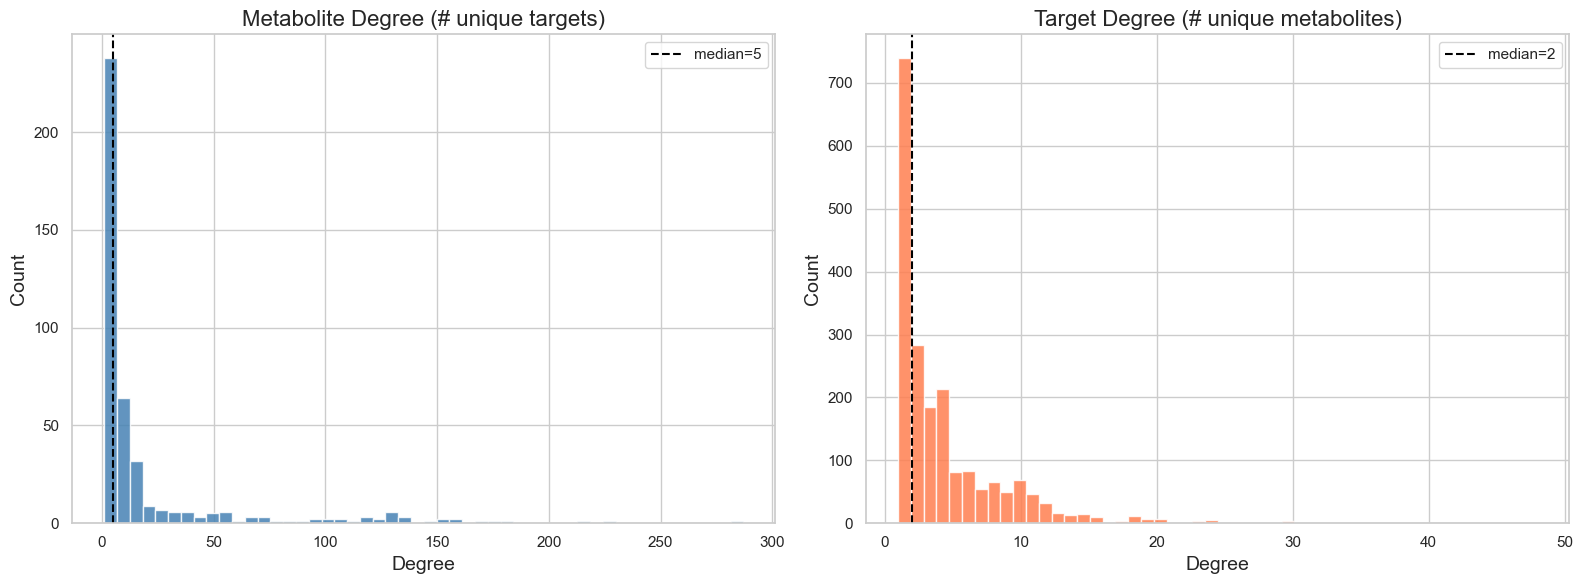

Metabolite degree: median=5, max=287 (n-acetylglucosamine)
Target degree: median=2, max=48 (PPARG)


In [5]:
met_degree = df.groupby('Metabolite_Name')['Target'].nunique().sort_values(ascending=False)
tgt_degree = df.groupby('Target')['Metabolite_Name'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title, color in [(axes[0], met_degree, 'Metabolite Degree (# unique targets)', 'steelblue'),
                                (axes[1], tgt_degree, 'Target Degree (# unique metabolites)', 'coral')]:
    ax.hist(data.values, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Degree'); ax.set_ylabel('Count'); ax.set_title(title)
    ax.axvline(data.median(), color='black', ls='--', label=f'median={data.median():.0f}')
    ax.legend()
plt.tight_layout(); plt.show()

print(f'Metabolite degree: median={met_degree.median():.0f}, max={met_degree.max()} ({met_degree.idxmax()})')
print(f'Target degree: median={tgt_degree.median():.0f}, max={tgt_degree.max()} ({tgt_degree.idxmax()})')

### 3.2. Top 20 Hub Metabolites & Targets

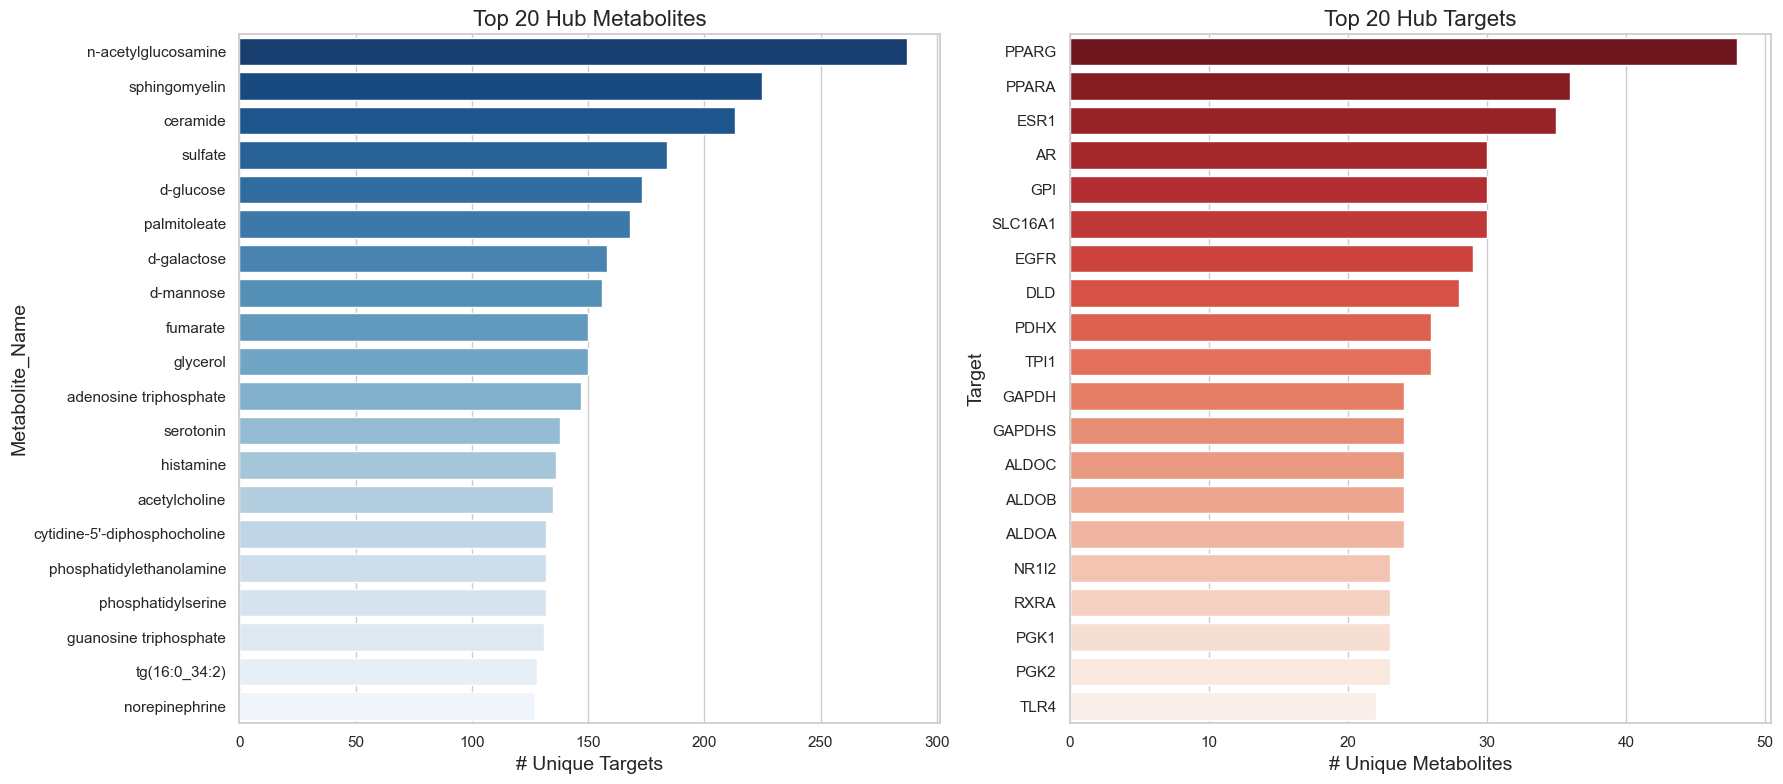

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.barplot(x=met_degree.head(20).values, y=met_degree.head(20).index, palette='Blues_r', hue=met_degree.head(20).index, legend=False, ax=axes[0])
axes[0].set_title('Top 20 Hub Metabolites'); axes[0].set_xlabel('# Unique Targets')
sns.barplot(x=tgt_degree.head(20).values, y=tgt_degree.head(20).index, palette='Reds_r', hue=tgt_degree.head(20).index, legend=False, ax=axes[1])
axes[1].set_title('Top 20 Hub Targets'); axes[1].set_xlabel('# Unique Metabolites')
plt.tight_layout(); plt.show()

---
## 4. Database Provenance & Confidence
### 4.1. Cross-Database Validation of Pairs

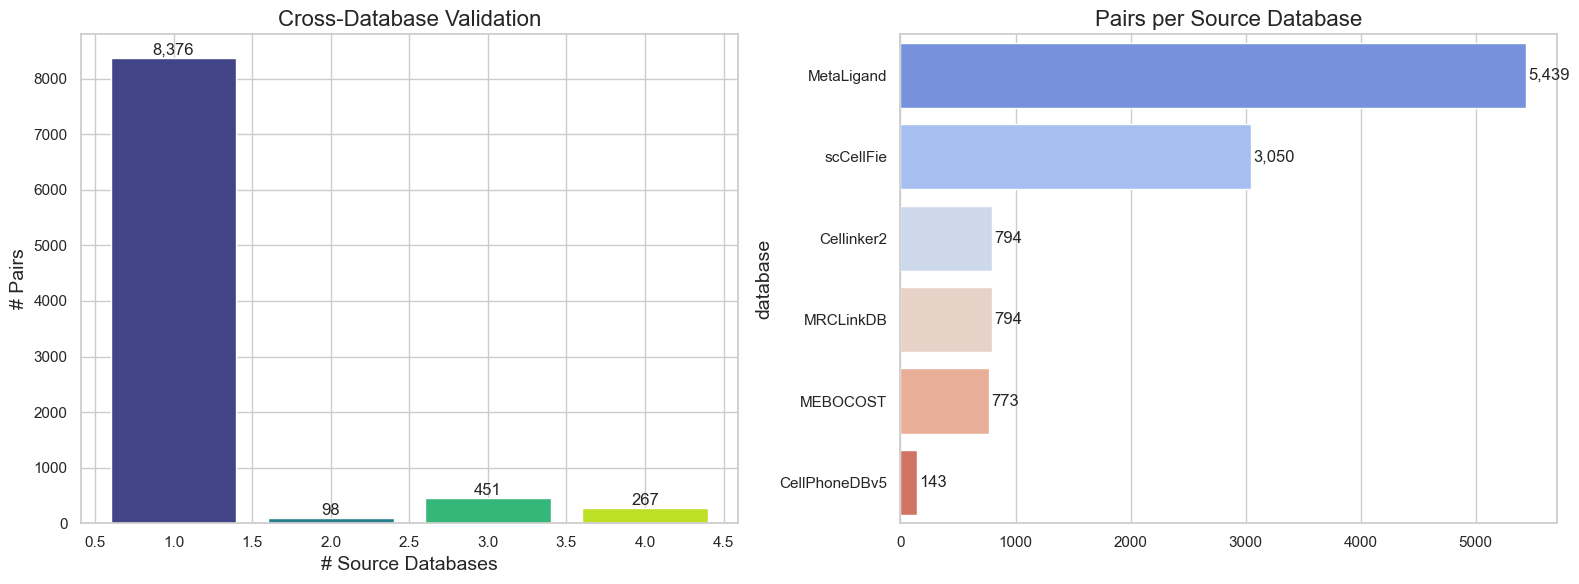


High-confidence pairs (3+ databases): 718 (7.8%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
vc = df['databases_count'].value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color=plt.cm.viridis(np.linspace(0.2,0.9,len(vc))), edgecolor='white')
for i, (x, y) in enumerate(zip(vc.index, vc.values)): axes[0].text(x, y, f'{y:,}', ha='center', va='bottom')
axes[0].set_xlabel('# Source Databases'); axes[0].set_ylabel('# Pairs'); axes[0].set_title('Cross-Database Validation')

db_pairs = df['database'].str.split(', ').explode().value_counts()
sns.barplot(x=db_pairs.values, y=db_pairs.index, palette='coolwarm', hue=db_pairs.index, legend=False, ax=axes[1])
axes[1].set_title('Pairs per Source Database')
for i, v in enumerate(db_pairs.values): axes[1].text(v+20, i, f'{v:,}', va='center')
plt.tight_layout(); plt.show()

print(f'\nHigh-confidence pairs (3+ databases): {(df["databases_count"]>=3).sum():,} ({(df["databases_count"]>=3).mean()*100:.1f}%)')

---
## 5. Interaction Biology
### 5.1. Sensor Type Distribution

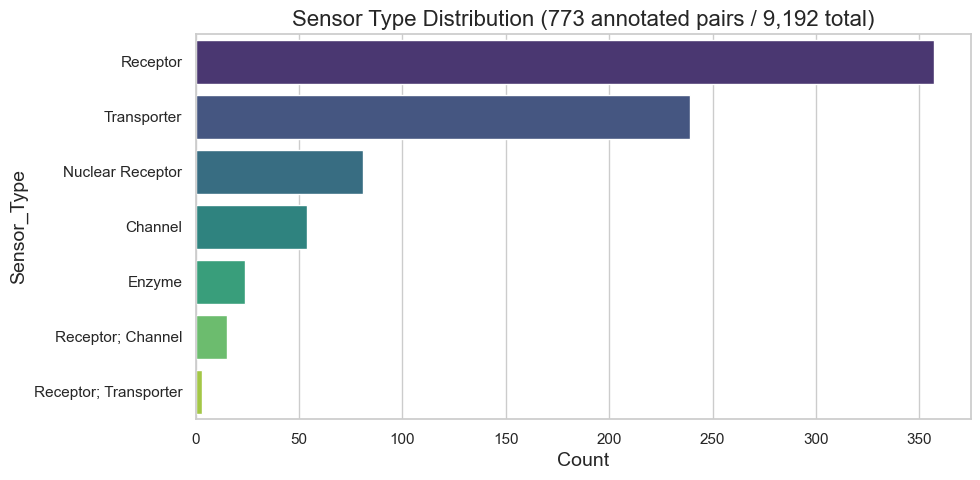

In [8]:
st = df['Sensor_Type'].value_counts(dropna=True)
plt.figure(figsize=(10, 5))
sns.barplot(x=st.values, y=st.index, palette='viridis', hue=st.index, legend=False)
plt.title(f'Sensor Type Distribution ({st.sum():,} annotated pairs / {len(df):,} total)')
plt.xlabel('Count'); plt.show()

### 5.2. Enzyme Product/Substrate Relationships

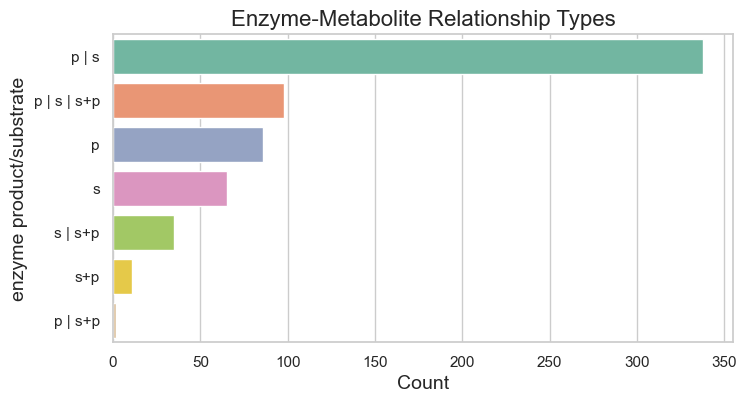


635 pairs have product/substrate annotations.


In [9]:
eps = df['enzyme product/substrate'].value_counts(dropna=True)
plt.figure(figsize=(8, 4))
sns.barplot(x=eps.values, y=eps.index, palette='Set2', hue=eps.index, legend=False)
plt.title('Enzyme-Metabolite Relationship Types'); plt.xlabel('Count'); plt.show()
print(f'\n{eps.sum()} pairs have product/substrate annotations.')

### 5.3. Interaction Type (Promote/Inhibit/Release/Consume)

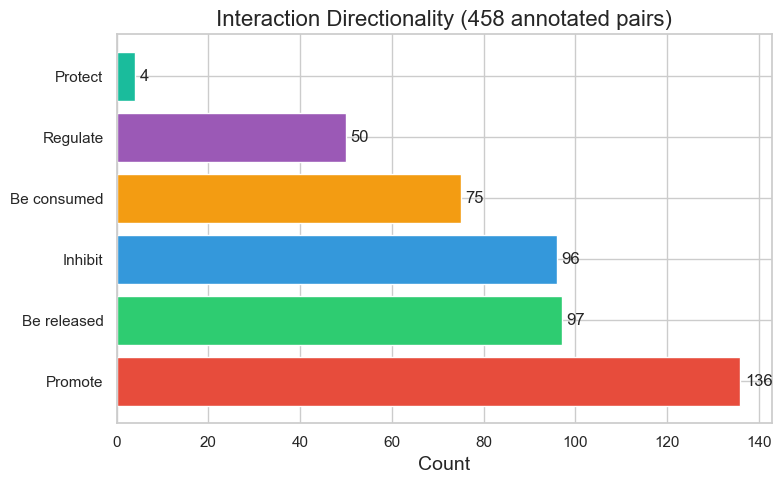

In [10]:
inter = df['Interaction'].value_counts(dropna=True)
colors_int = {'Promote': '#e74c3c', 'Inhibit': '#3498db', 'Be released': '#2ecc71', 'Be consumed': '#f39c12', 'Regulate': '#9b59b6', 'Protect': '#1abc9c'}
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(inter.index, inter.values, color=[colors_int.get(i, '#95a5a6') for i in inter.index])
ax.set_xlabel('Count'); ax.set_title(f'Interaction Directionality ({inter.sum()} annotated pairs)')
for i, v in enumerate(inter.values): ax.text(v+1, i, str(v), va='center')
plt.tight_layout(); plt.show()

---
## 6. Chemical & Metabolic Classification
### 6.1. SuperClass of Interacting Metabolites

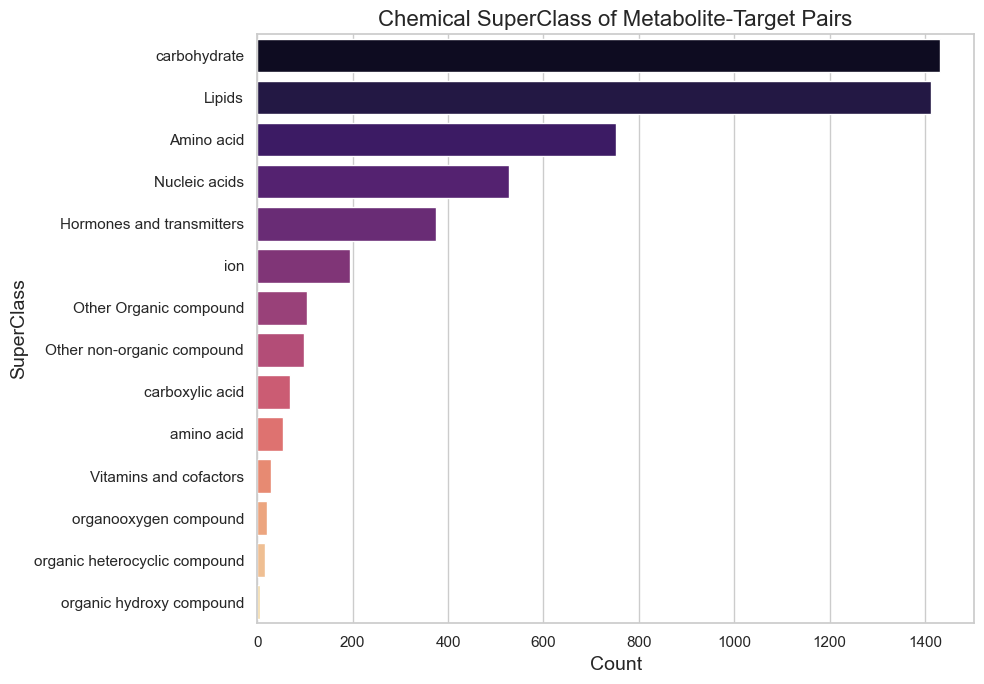

In [11]:
sc = df['SuperClass'].value_counts(dropna=True)
plt.figure(figsize=(10, 7))
sns.barplot(x=sc.values, y=sc.index, palette='magma', hue=sc.index, legend=False)
plt.title('Chemical SuperClass of Metabolite-Target Pairs')
plt.xlabel('Count'); plt.tight_layout(); plt.show()

### 6.2. Metabolic System & Subsystem (scCellFie)

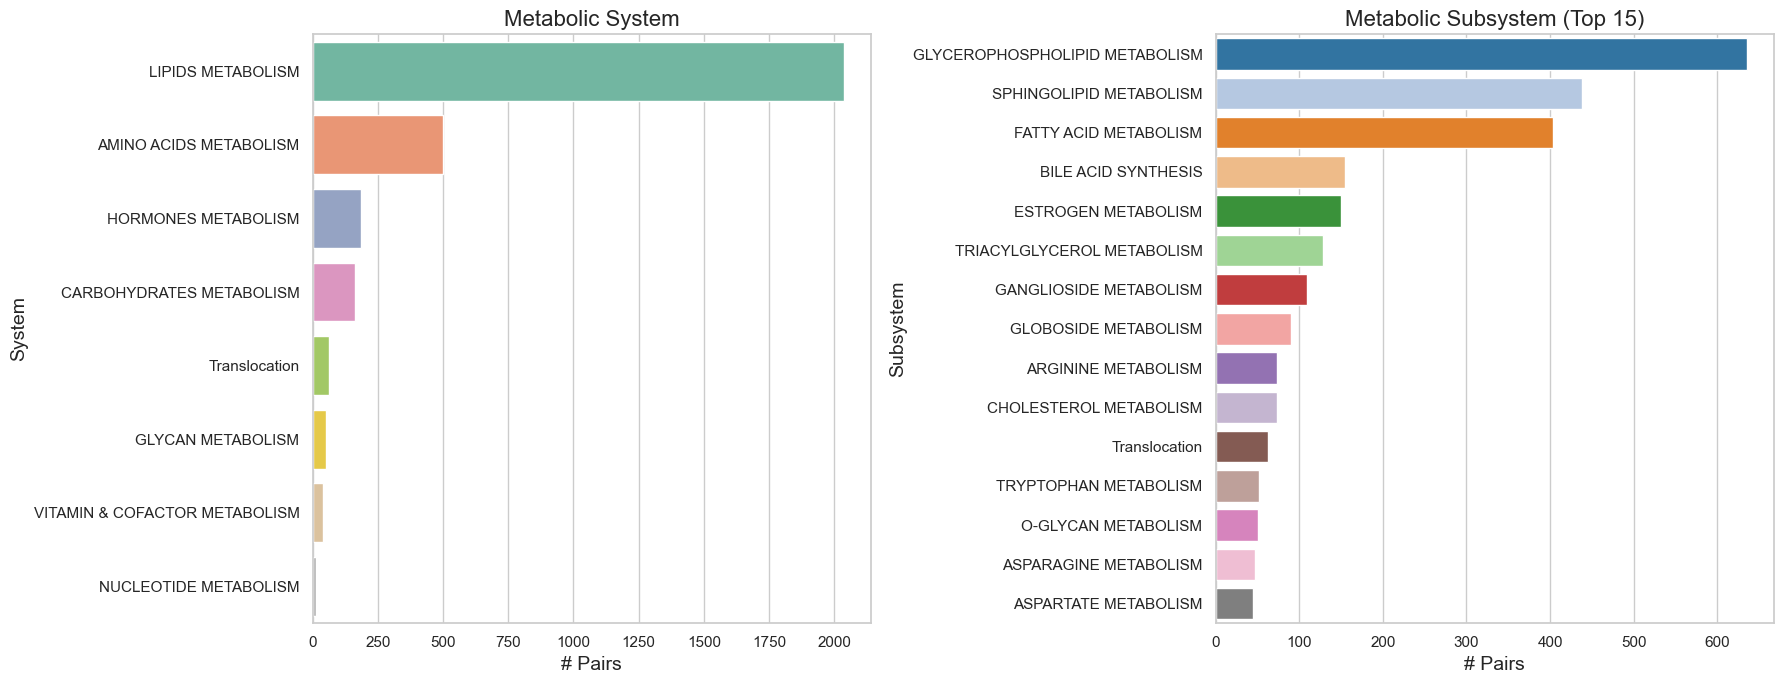


scCellFie metabolic scores available for 3,050 pairs.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, col, title, pal in [(axes[0], 'System', 'Metabolic System', 'Set2'), (axes[1], 'Subsystem', 'Metabolic Subsystem (Top 15)', 'tab20')]:
    vc = df[col].value_counts(dropna=True).head(15)
    sns.barplot(x=vc.values, y=vc.index, palette=pal, hue=vc.index, legend=False, ax=ax)
    ax.set_title(title); ax.set_xlabel('# Pairs')
plt.tight_layout(); plt.show()
print(f'\nscCellFie metabolic scores available for {df["scCellFie_value"].notna().sum():,} pairs.')

---
## 7. Cancer-Relevant Analysis
### 7.1. Disease Annotations

**Data Provenance & Backtrack Info:**  
The metadata in columns `Disease`, `Cell type`, `Effect`, and `Interaction` is specific to the **MRCLinkDB** source. 

- **Source File:** `MRCLinkDB/Metabolite-cell interaction.txt`  
- **Ingestion Logic:** Handled in `scripts/merge_dbs_claude.py` within the `process_mrclinkdb()` function. The script specifically maps the clinical metadata provided by MRCLinkDB during the initial consolidation phase.  
- **Merge Strategy:** These annotations are carried through the pipeline only for pairs found in MRCLinkDB. For metabolites sourced from other databases (e.g., MEBOCOST, CellPhoneDBv5), these fields remain empty (`NaN`) as those databases do not provide clinical disease context in their raw ligand-receptor mapping.  

This backtrack ensures that any disease-specific results observed below can be directly attributed to the expert-curated interactions in the MRCLinkDB dataset.

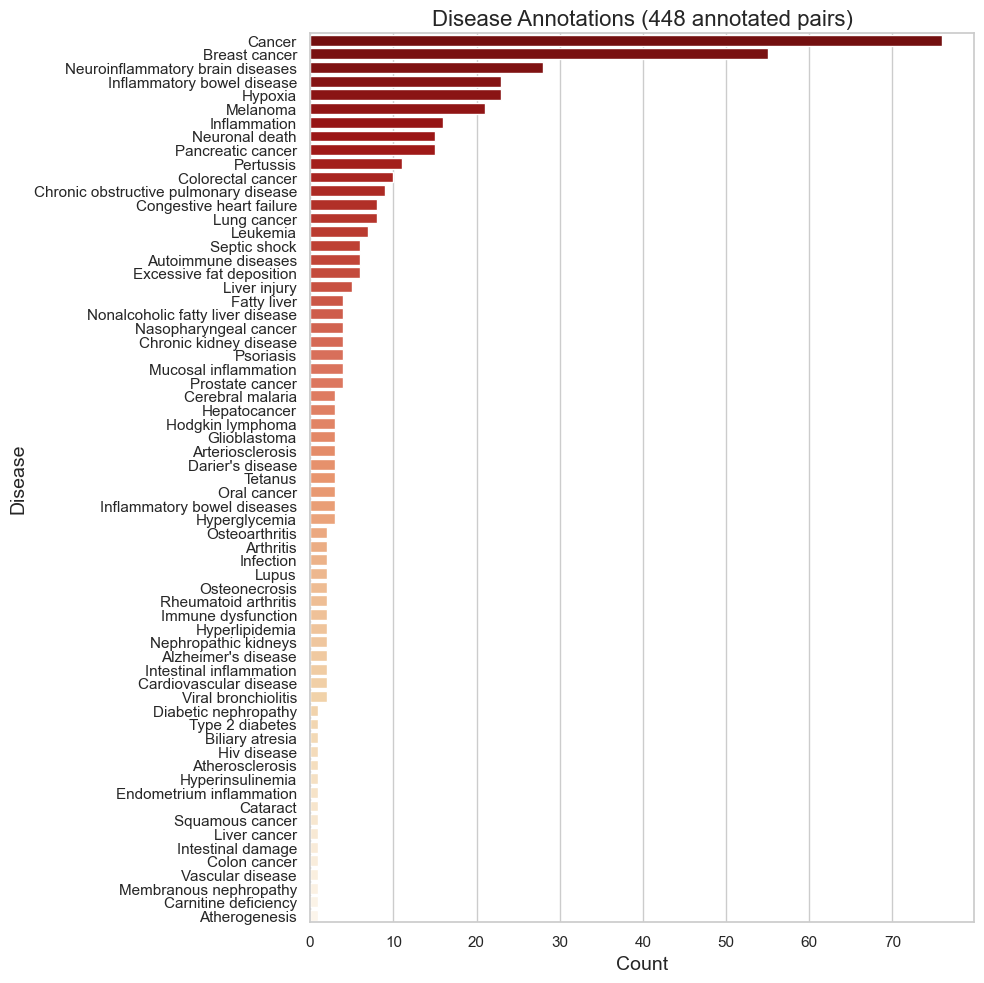


→ 212 pairs have explicit cancer/tumor disease annotations.
→ Covering 52 metabolites and 160 targets.


In [14]:
disease_vc = df['Disease'].value_counts(dropna=True)
plt.figure(figsize=(10, 10))
sns.barplot(x=disease_vc.values, y=disease_vc.index, palette='OrRd_r', hue=disease_vc.index, legend=False)
plt.title(f'Disease Annotations ({disease_vc.sum()} annotated pairs)'); plt.xlabel('Count')
plt.tight_layout(); plt.show()

cancer_terms = ['Cancer', 'cancer', 'carcinoma', 'Melanoma', 'melanoma', 'tumor', 'Tumor', 'leukemia', 'lymphoma']
cancer_mask = df['Disease'].str.contains('|'.join(cancer_terms), case=False, na=False)
print(f'\n→ {cancer_mask.sum()} pairs have explicit cancer/tumor disease annotations.')
print(f'→ Covering {df.loc[cancer_mask, "Metabolite_Name"].nunique()} metabolites and {df.loc[cancer_mask, "Target"].nunique()} targets.')

### 7.2. Cell Type Annotations

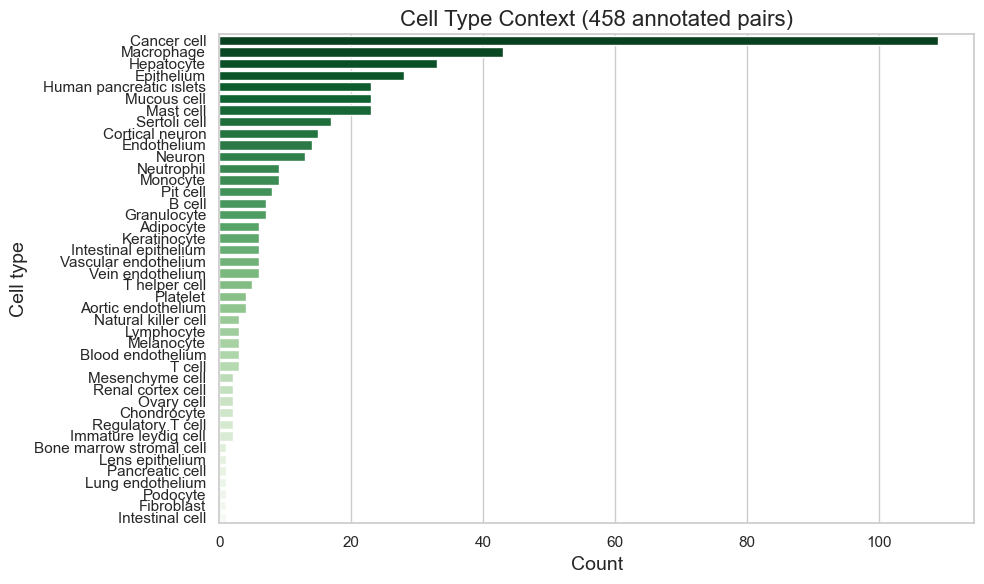

In [15]:
ct = df['Cell type'].value_counts(dropna=True)
plt.figure(figsize=(10, 6))
sns.barplot(x=ct.values, y=ct.index, palette='Greens_r', hue=ct.index, legend=False)
plt.title(f'Cell Type Context ({ct.sum()} annotated pairs)'); plt.xlabel('Count')
plt.tight_layout(); plt.show()

### 7.3. Cancer Cell Interactions: Effect & Directionality

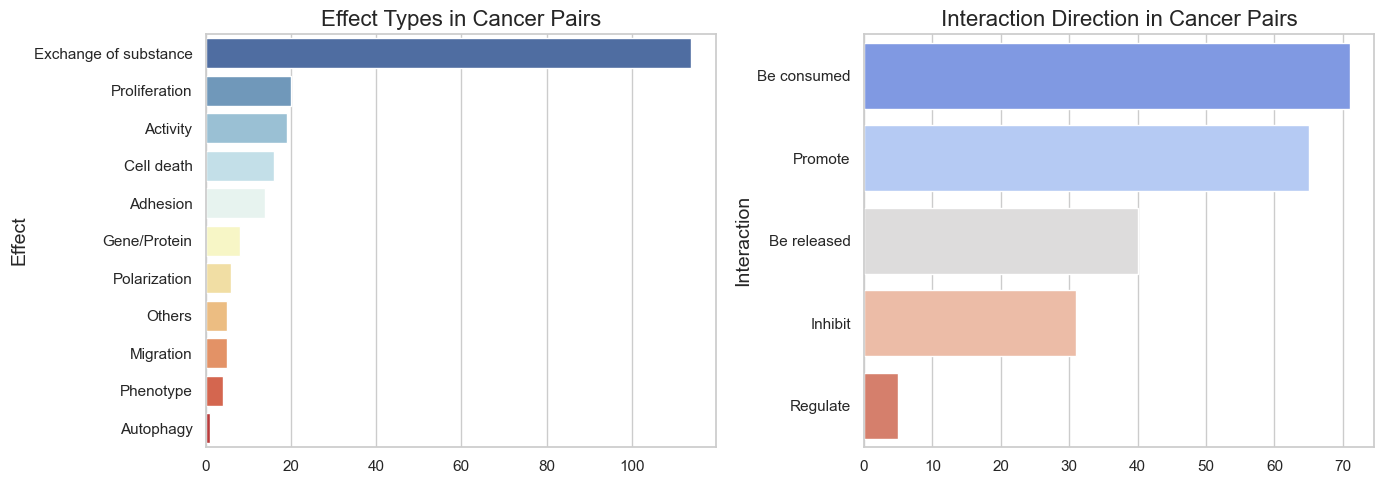


=== Top Cancer-Associated Metabolites ===
Metabolite_Name
serotonin                 23
adenosine triphosphate    20
l-glutamine               15
norepinephrine            13
d-glucose                 10
vitamin a                  8
l-aspartate                6
l-serine                   6
l-phenylalanine            6
25-hydroxycholesterol      5

=== Top Cancer-Associated Targets ===
Target
GPRC6A      6
SLC43A1     6
SLC7A5      5
SLC1A5      4
ESR1        3
SLC43A2     3
SLC16A10    3
SLC16A1     3
SLC3A2      3
SLC22A1     3


In [17]:
cancer_df = df[cancer_mask].copy()
if len(cancer_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Effect types in cancer
    eff = cancer_df['Effect'].value_counts(dropna=True)
    sns.barplot(x=eff.values, y=eff.index, palette='RdYlBu_r', hue=eff.index, legend=False, ax=axes[0])
    axes[0].set_title('Effect Types in Cancer Pairs')
    # Interaction direction in cancer
    inter_c = cancer_df['Interaction'].value_counts(dropna=True)
    if len(inter_c) > 0:
        sns.barplot(x=inter_c.values, y=inter_c.index, palette='coolwarm', hue=inter_c.index, legend=False, ax=axes[1])
    axes[1].set_title('Interaction Direction in Cancer Pairs')
    plt.tight_layout(); plt.show()

    print('\n=== Top Cancer-Associated Metabolites ===')
    print(cancer_df['Metabolite_Name'].value_counts().head(10).to_string())
    print('\n=== Top Cancer-Associated Targets ===')
    print(cancer_df['Target'].value_counts().head(10).to_string())
else:
    print('No cancer-annotated pairs found.')

---
## 8. CCC Readiness: Sender–Receiver Gene Pairs
Pairs that have BOTH `Synthetic_genes` (sender/producer) AND `Sensor_Gene` or `Target` (receiver/sensor) are directly usable for cell-cell communication scoring with expression data.

Total pairs: 9,192
Has sender gene (Synthetic_genes): 5,309 (57.8%)
Has receiver gene (Sensor_Gene):    773
CCC-ready pairs (sender + receiver): 5,309 (57.8%)


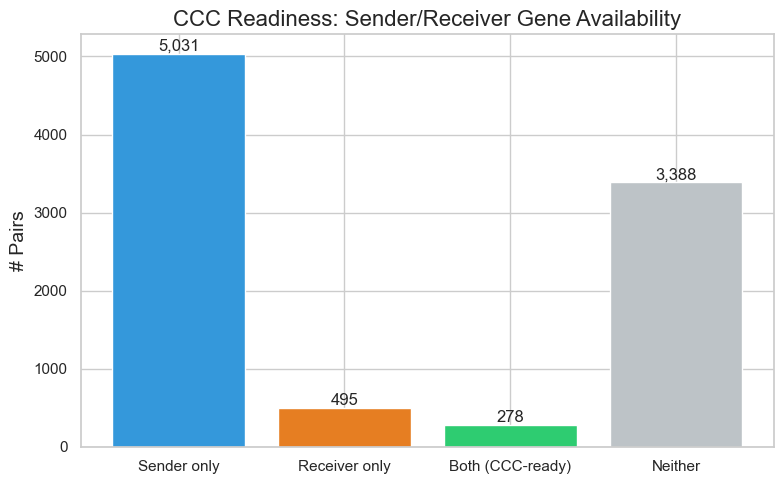

In [18]:
has_sender = df['Synthetic_genes'].notna()
has_receiver = df['Sensor_Gene'].notna() | df['Target'].notna()
ccc_ready = has_sender & has_receiver

print(f'Total pairs: {len(df):,}')
print(f'Has sender gene (Synthetic_genes): {has_sender.sum():,} ({has_sender.mean()*100:.1f}%)')
print(f'Has receiver gene (Sensor_Gene):    {df["Sensor_Gene"].notna().sum():,}')
print(f'CCC-ready pairs (sender + receiver): {ccc_ready.sum():,} ({ccc_ready.mean()*100:.1f}%)')

# Venn-like summary
fig, ax = plt.subplots(figsize=(8, 5))
cats = ['Sender only', 'Receiver only', 'Both (CCC-ready)', 'Neither']
vals = [
    (has_sender & ~df['Sensor_Gene'].notna()).sum(),
    (~has_sender & df['Sensor_Gene'].notna()).sum(),
    (has_sender & df['Sensor_Gene'].notna()).sum(),
    (~has_sender & ~df['Sensor_Gene'].notna()).sum()
]
colors_v = ['#3498db', '#e67e22', '#2ecc71', '#bdc3c7']
ax.bar(cats, vals, color=colors_v)
for i, v in enumerate(vals): ax.text(i, v, f'{v:,}', ha='center', va='bottom')
ax.set_ylabel('# Pairs'); ax.set_title('CCC Readiness: Sender/Receiver Gene Availability')
plt.tight_layout(); plt.show()

---
## 9. High-Confidence Multi-DB Pairs
Pairs validated across 3+ databases with complete gene annotations.

In [19]:
hc = df[(df['databases_count'] >= 3) & ccc_ready].copy()
print(f'High-confidence CCC-ready pairs: {len(hc):,}')
print(f'  Unique metabolites: {hc["Metabolite_Name"].nunique()}')
print(f'  Unique targets: {hc["Target"].nunique()}')

if len(hc) > 0:
    print('\n=== Top Metabolites in High-Confidence Set ===')
    print(hc['Metabolite_Name'].value_counts().head(15).to_string())
    print('\n=== Top Targets in High-Confidence Set ===')
    print(hc['Target'].value_counts().head(15).to_string())

High-confidence CCC-ready pairs: 264
  Unique metabolites: 79
  Unique targets: 194

=== Top Metabolites in High-Confidence Set ===
Metabolite_Name
l-glutamate                25
acetylcholine              21
adenosine triphosphate     19
serotonin                  19
gamma-aminobutyric acid    14
glycine                     9
sphingosine 1-phosphate     9
epinephrine                 8
norepinephrine              8
dopamine                    5
cyclic gmp                  5
cholesterol                 4
all-trans-retinoic acid     4
uridine triphosphate        4
9-cis-retinoic acid         4

=== Top Targets in High-Confidence Set ===
Target
ESR1      5
GPRC6A    4
FFAR4     4
GPR17     4
GRIN2D    3
GRIN2A    3
NR3C2     3
GRIN1     3
TRPM2     3
TAAR1     3
P2RY14    3
NR3C1     3
NR1H3     3
GRIN2C    3
RXRG      3


---
## 10. Target Gene Lists for Downstream Integration
Export curated gene lists for TCGA/GEO expression lookups.

In [20]:
# All unique target genes
all_targets = df['Target'].dropna().unique()
print(f'All unique target genes: {len(all_targets)}')

# Sender genes
sender_genes = df['Synthetic_genes'].dropna().str.split(',').explode().str.strip().unique()
print(f'All unique sender genes: {len(sender_genes)}')

# Sensor genes
sensor_genes = df['Sensor_Gene'].dropna().unique()
print(f'All unique sensor genes: {len(sensor_genes)}')

# Save for downstream
os.makedirs('../output/gene_lists', exist_ok=True)
pd.Series(all_targets).to_csv('../output/gene_lists/all_target_genes.txt', index=False, header=False)
pd.Series(sender_genes).to_csv('../output/gene_lists/sender_genes.txt', index=False, header=False)
pd.Series(sensor_genes).to_csv('../output/gene_lists/sensor_genes.txt', index=False, header=False)
print('\n→ Gene lists saved to output/gene_lists/ for TCGA/GEO queries.')

All unique target genes: 2007
All unique sender genes: 2053
All unique sensor genes: 413

→ Gene lists saved to output/gene_lists/ for TCGA/GEO queries.


---
## 11. Summary Statistics

In [21]:
summary = {
    'Total interaction pairs': f'{len(df):,}',
    'Unique metabolites': df['Metabolite_Name'].nunique(),
    'Unique targets': df['Target'].nunique(),
    'Cancer-annotated pairs': cancer_mask.sum(),
    'CCC-ready pairs (sender+receiver)': ccc_ready.sum(),
    'High-conf CCC-ready (3+ DB)': len(hc),
    'With Sensor_Type annotation': df['Sensor_Type'].notna().sum(),
    'With Disease annotation': df['Disease'].notna().sum(),
    'With scCellFie score': df['scCellFie_value'].notna().sum(),
    'With Evidence_Score': df['Evidence_Score'].notna().sum(),
}
pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])

,Value
Total interaction pairs,"9,192"
Unique metabolites,418
Unique targets,2007
Cancer-annotated pairs,212
CCC-ready pairs (sender+receiver),5309
High-conf CCC-ready (3+ DB),264
With Sensor_Type annotation,773
With Disease annotation,448
With scCellFie score,3050
With Evidence_Score,432
